In [620]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from matplotlib.patches import Patch

In [621]:
df = pd.DataFrame.from_dict({
    0 : {"n_kernels":4, "n_regions":4, "occupancy":1.00, "fanin_memory_controller_0":4, "fanin_memory_controller_1":0, "speedup":0.68, "tat" : 0.70},
    1 : {"n_kernels":4, "n_regions":4, "occupancy":1.00, "fanin_memory_controller_0":2, "fanin_memory_controller_1":2, "speedup":1.34, "tat" : 1.34},
    2 : {"n_kernels":4, "n_regions":4, "occupancy":1.00, "fanin_memory_controller_0":3, "fanin_memory_controller_1":1, "speedup":0.88, "tat" : 0.90},
    3 : {"n_kernels":3, "n_regions":4, "occupancy":0.75, "fanin_memory_controller_0":2, "fanin_memory_controller_1":1, "speedup":1.74, "tat" : 1.67},
    4 : {"n_kernels":3, "n_regions":4, "occupancy":0.75, "fanin_memory_controller_0":3, "fanin_memory_controller_1":0, "speedup":0.68, "tat" : 0.70},
    5 : {"n_kernels":2, "n_regions":4, "occupancy":0.50, "fanin_memory_controller_0":1, "fanin_memory_controller_1":1, "speedup":1.98, "tat" : 1.88},
}, orient="index")

In [622]:
df

,n_kernels,n_regions,occupancy,fanin_memory_controller_0,fanin_memory_controller_1,speedup,tat
0,4,4,1.00,4,0,0.68,0.70
1,4,4,1.00,2,2,1.34,1.34
2,4,4,1.00,3,1,0.88,0.90
3,3,4,0.75,2,1,1.74,1.67
4,3,4,0.75,3,0,0.68,0.70
5,2,4,0.50,1,1,1.98,1.88


In [623]:
df = pd.DataFrame.from_dict({
    0 : {"n_kernels":4, "n_regions":4, "occupancy":1.00, "fanin_memory_controller_0":4, "fanin_memory_controller_1":0, "speedup":0.57, "tat" : 0.59},
    1 : {"n_kernels":3, "n_regions":4, "occupancy":0.75, "fanin_memory_controller_0":3, "fanin_memory_controller_1":0, "speedup":0.88, "tat" : 0.68},
    2 : {"n_kernels":2, "n_regions":4, "occupancy":0.50, "fanin_memory_controller_0":2, "fanin_memory_controller_1":0, "speedup":1.72, "tat" : 1.13},
}, orient="index")

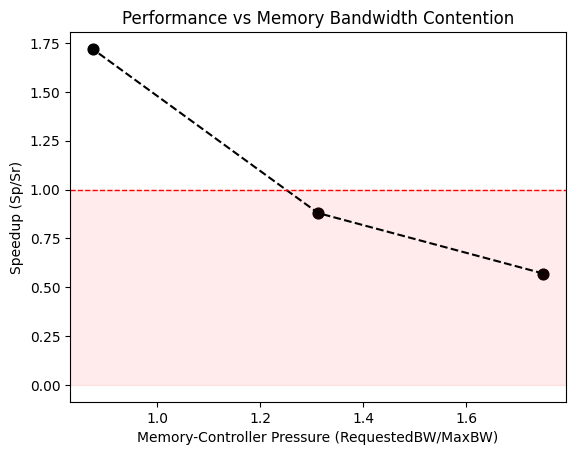

In [624]:
x, y = (1.75 * df["fanin_memory_controller_0"] * 256) / (4 * 256), df["speedup"]

plt.scatter(x, y, marker="o", s=60, color="black")
plt.plot(x, y, '--', color="black")
# Baseline line
plt.axhline(1.0, linestyle="--", linewidth=1, color="r")

# Shade slowdown region
plt.axhspan(0, 1.0, alpha=0.08, color="red")

plt.title("Performance vs Memory Bandwidth Contention")
plt.xlabel("Memory-Controller Pressure (RequestedBW/MaxBW)")
plt.ylabel("Speedup (Sp/Sr)")

coef = np.polyfit(x, y, deg=1)
poly = np.poly1d(coef)


plt.show()

### Metrics Proposal
---
- Define a workload [mm2, mvt, ...]
1. Baseline :
    - ❌ Parallel execution 
    - ❌ Migration 
    - ❌ Stateful
2. Shared Platform :
    - ✅ Parallel execution
    - ❌ Migration
    - ❌ Stateful
3. Naive Defragmentation:
    - ✅ Parallel execution
    - ✅ Migration
    - ❌ Stateful
4. Efficient Defragmentation:
    - ✅ Parallel execution
    - ✅ Migration
    - ✅ Stateful

In [625]:
hatches = ['-', '/', '||', '*', '+', '--']
color_stack = ["#212db5", "#b52166", "#b58921"]
color_bars  = ["#212db5", "#b52166", "#b58921"]

# Hardware

            jobs     mean_wait  mean_config     mean_exec  \
mode                                                        
Monolithic  1024  6.052025e+08  3672.745117  1.288723e+06   
Tiled       1024  1.619820e+08  3407.727539  4.128338e+06   

            mean_turnaround_time  tail_latency_p95  tail_latency_p99  \
mode                                                                   
Monolithic          6.064949e+08      1.260897e+09      1.310896e+09   
Tiled               1.661138e+08      3.649206e+08      3.875595e+08   

            max_turnaround   min_arrival  max_completion    makespan  \
mode                                                                   
Monolithic      1322915489  382056588813    383380122232  1323533419   
Tiled            390986618  381664736416    382056299958   391563542   

            throughput_jobs_per_sec  
mode                                 
Monolithic                 0.773687  
Tiled                      2.615157  


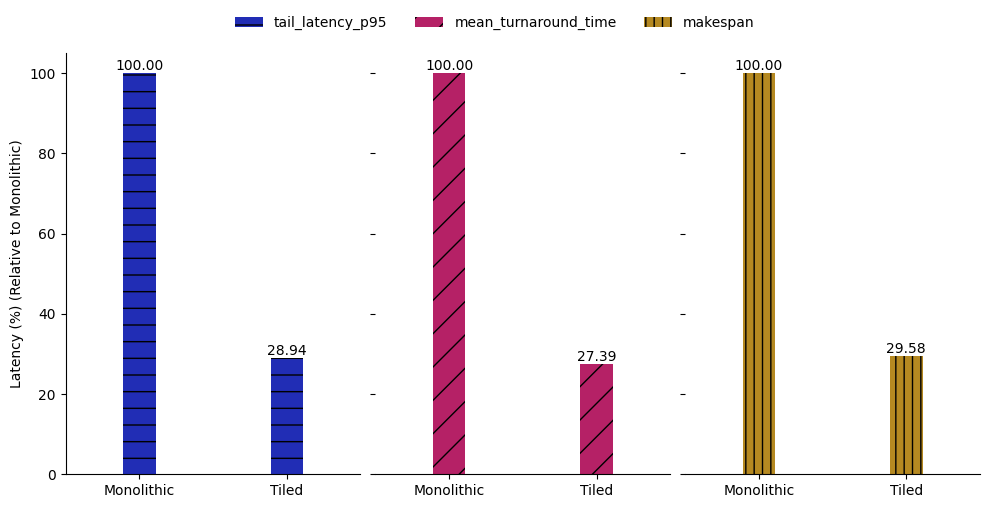

In [626]:
metrics = pd.read_csv("./metrics.csv")

metrics["t_wait"]        = metrics["t_scheduled"] - metrics["t_arrival"]
metrics["t_config"]      = metrics["t_configured"] - metrics["t_scheduled"]
metrics["t_exec"]        = metrics["t_completed"] - metrics["t_configured"]

metrics["kernel_turnaround"] = metrics["t_completed"] - metrics["t_arrival"]

summary = metrics.groupby("mode").agg(
    jobs                   = ("kernel_id", "count"),
    mean_wait              = ("t_wait", "mean"),
    mean_config            = ("t_config", "mean"),
    mean_exec              = ("t_exec", "mean"),
    mean_turnaround_time   = ("kernel_turnaround", "mean"),
    tail_latency_p95       = ("kernel_turnaround", lambda x: x.quantile(0.95)),
    tail_latency_p99       = ("kernel_turnaround", lambda x: x.quantile(0.99)),
    max_turnaround         = ("kernel_turnaround", "max"),
    min_arrival            = ("t_arrival", "min"),
    max_completion         = ("t_completed", "max"),
)

summary["makespan"] = (
    summary["max_completion"] - summary["min_arrival"]
)

summary["throughput_jobs_per_sec"] = (
    summary["jobs"] / (summary["makespan"] / 1e6)
)


print(summary)

summary_normalized = summary / summary.iloc[0] * 100.0

ratio_metrics = summary_normalized[["tail_latency_p95", "mean_turnaround_time", "makespan"]].to_dict()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5), squeeze=False, sharey=True)

legend_handles = []

for i, (_ax, (name, series)) in enumerate(zip(ax.flatten(), ratio_metrics.items())):
    
    # _ax.set_title(name)

    bars = _ax.bar(series.keys(), series.values(), width=0.22, color=color_bars[i])

    _ax.bar_label(bars, label_type='edge', fmt='%.2f')

    num_categories = len(series)

    _ax.set_xlim(-0.5, num_categories - 0.5)

    _ax.set_aspect('auto')

    [bar.set_hatch(hatches[i]) for bar in bars]

    _ax.spines['top'].set_visible(False)
    
    _ax.spines['right'].set_visible(False)

    if i > 0:
        _ax.spines['left'].set_visible(False)

    legend_handles.append(
        Patch(facecolor=color_bars[i], hatch=hatches[i], label=name)
    )

ax[0,0].set_ylabel("Latency (%) (Relative to Monolithic)")

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=len(legend_handles),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("hw_improvement.png", dpi=600, bbox_inches="tight")
plt.show()

In [627]:
metrics.groupby("mode")["t_exec"].min(), metrics.groupby("mode")["t_exec"].max()

(mode
 Monolithic     465
 Tiled         1535
 Name: t_exec, dtype: int64,
 mode
 Monolithic    1925264
 Tiled         7436614
 Name: t_exec, dtype: int64)

In [628]:
summary.loc['Monolithic']["tail_latency_p95"] / summary.loc['Tiled']["tail_latency_p95"]

np.float64(3.4552633277179194)

In [629]:
metrics

,kernel_id,run_name,mode,kname,status,t_arrival,t_scheduled,t_configured,t_completed,t_wait,t_config,t_exec,kernel_turnaround
0,0,parallel,Tiled,saxpy,COMPLETED,381664736416,381664736546,381664917843,381665097169,130,181297,179326,360753
1,1,parallel,Tiled,saxpy,COMPLETED,381664917882,381665211676,381665260217,381665313470,293794,48541,53253,395588
2,2,parallel,Tiled,2mm,COMPLETED,381664917909,381665260223,381665264954,381671434205,342314,4731,6169251,6516296
3,3,parallel,Tiled,matmul,COMPLETED,381664917972,381665264976,381665267387,381671449386,347004,2411,6181999,6531414
4,4,parallel,Tiled,saxpy,COMPLETED,381664918017,381665267395,381665269679,381665313475,349378,2284,43796,395458
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,2043,serial,Monolithic,saxpy,COMPLETED,382057206594,383376258401,383376260851,383376261553,1319051807,2450,702,1319054959
2044,2044,serial,Monolithic,saxpy,COMPLETED,382057206633,383376261666,383376264229,383376264926,1319055033,2563,697,1319058293
2045,2045,serial,Monolithic,matmul,COMPLETED,382057206685,383376265059,383376267583,383378192116,1319058374,2524,1924533,1320985431
2046,2046,serial,Monolithic,saxpy,COMPLETED,382057206715,383378192227,383378194654,383378195122,1320985512,2427,468,1320988407


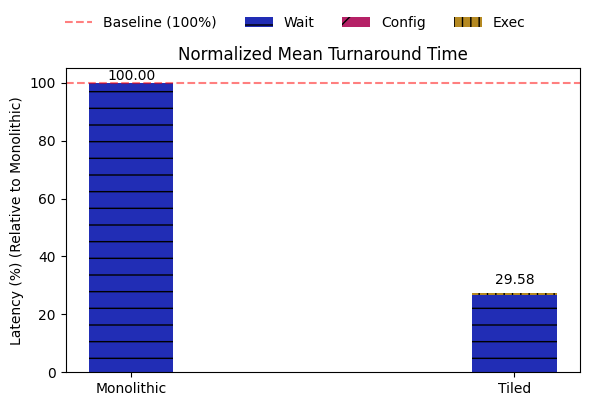

In [630]:
# 1. Calculate the total baseline from the monolithic row
# Sum of the three metrics for the monolithic mode
baseline_total = summary.loc['Monolithic', ["mean_wait", "mean_config", "mean_exec"]].sum()

# 2. Create a normalized dataframe (Values as % of Monolithic baseline)
summary_norm = summary[["mean_wait", "mean_config", "mean_exec"]] / baseline_total * 100.0

# 3. Plotting using the normalized data
stacked = summary_norm.to_dict()
labels = summary_norm.index

wait = [stacked['mean_wait'][l] for l in labels]
config = [stacked['mean_config'][l] for l in labels]
exec = [stacked['mean_exec'][l] for l in labels]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(6, 4))

_ = ax.bar(x, wait, label='Wait', width=0.22, color=color_stack[0])
[_.set_hatch(hatches[0]) for _ in _]

_ = ax.bar(x, config, bottom=wait, label='Config', width=0.22, color=color_stack[1])
[_.set_hatch(hatches[1]) for _ in _]

bottom_exec = np.array(wait) + np.array(config)
_ = ax.bar(x, exec, bottom=bottom_exec, label='Exec', width=0.22, color=color_stack[2])
[_.set_hatch(hatches[2]) for _ in _]

ax.bar_label(bars, label_type='edge', fmt='%.2f')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Latency (%) (Relative to Monolithic)")
ax.set_title("Normalized Mean Turnaround Time")

ax.axhline(100, color='red', linestyle='--', alpha=0.5, label='Baseline (100%)')

fig.legend(
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("hw_improvement_stacked.png", dpi=600, bbox_inches="tight")

plt.show()

In [631]:
print(
    exec[1] / exec[0],
    wait[0] / wait[1],
    config[0] / config[1]
)

3.2034338325708336 3.736231973120262 1.0777695913441216


# Simulation

                jobs     mean_wait  mean_config     mean_exec  \
mode                                                            
monolithic       128  5.081103e+07     4171.875  7.521349e+05   
stateful         128  1.691589e+07     4171.875  2.258383e+06   
stateless(0.8)   128  1.713576e+07     4171.875  2.257229e+06   
stateless(1.0)   128  1.772693e+07     4171.875  2.303074e+06   
tiled            128  2.059771e+07     4171.875  2.256405e+06   

                mean_turnaround_time  tail_latency_p95  tail_latency_p99  \
mode                                                                       
monolithic              5.156734e+07       92930696.60       94355204.47   
stateful                1.917845e+07       34740586.65       40519311.03   
stateless(0.8)          1.939716e+07       34719326.05       40494311.48   
stateless(1.0)          2.003418e+07       38487019.60       40516285.86   
tiled                   2.285828e+07       40474724.25       46252551.48   

           

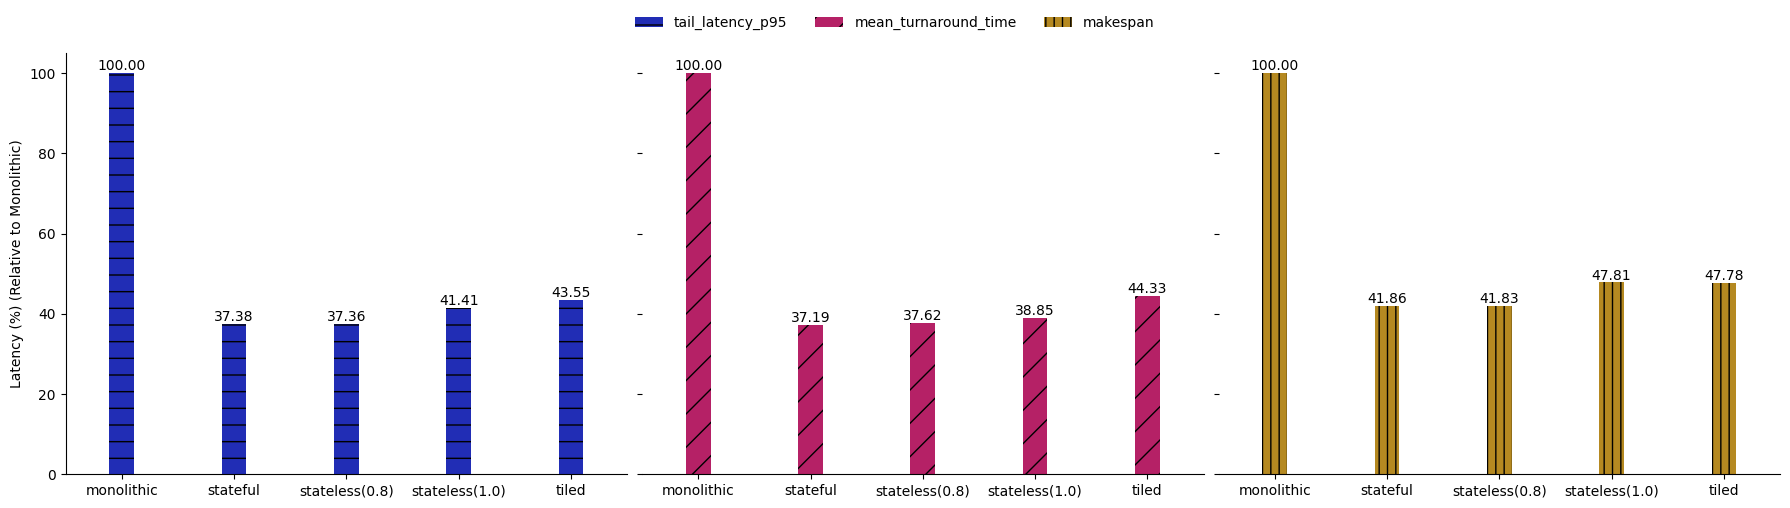

In [632]:
metrics = pd.read_csv("./sim_metrics.csv")

metrics["t_wait"]        = metrics["t_scheduled"] - metrics["t_arrival"]
metrics["t_config"]      = metrics["t_configured"] - metrics["t_scheduled"]
metrics["t_exec"]        = metrics["t_completed"] - metrics["t_configured"]

metrics["kernel_turnaround"] = metrics["t_completed"] - metrics["t_arrival"]

summary = metrics.groupby("mode").agg(
    jobs                   = ("kernel_id", "count"),
    mean_wait              = ("t_wait", "mean"),
    mean_config            = ("t_config", "mean"),
    mean_exec              = ("t_exec", "mean"),
    mean_turnaround_time   = ("kernel_turnaround", "mean"),
    tail_latency_p95       = ("kernel_turnaround", lambda x: x.quantile(0.95)),
    tail_latency_p99       = ("kernel_turnaround", lambda x: x.quantile(0.99)),
    max_turnaround         = ("kernel_turnaround", "max"),
    min_arrival            = ("t_arrival", "min"),
    max_completion         = ("t_completed", "max"),
)

summary["makespan"] = (
    summary["max_completion"] - summary["min_arrival"]
)

summary["throughput_jobs_per_sec"] = (
    summary["jobs"] / (summary["makespan"] / 1e6)
)


print(summary)

summary_normalized = summary / summary.iloc[0] * 100.0

ratio_metrics = summary_normalized[["tail_latency_p95", "mean_turnaround_time", "makespan"]].to_dict()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), squeeze=False, sharey=True)

legend_handles = []

for i, (_ax, (name, series)) in enumerate(zip(ax.flatten(), ratio_metrics.items())):
    
    # _ax.set_title(name)

    bars = _ax.bar(series.keys(), series.values(), width=0.22, color=color_bars[i])

    _ax.bar_label(bars, label_type='edge', fmt='%.2f')

    num_categories = len(series)

    _ax.set_xlim(-0.5, num_categories - 0.5)

    _ax.set_aspect('auto')

    [bar.set_hatch(hatches[i]) for bar in bars]

    _ax.spines['top'].set_visible(False)
    
    _ax.spines['right'].set_visible(False)

    if i > 0:
        _ax.spines['left'].set_visible(False)

    legend_handles.append(
        Patch(facecolor=color_bars[i], hatch=hatches[i], label=name)
    )


ax[0,0].set_ylabel("Latency (%) (Relative to Monolithic)")

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=len(legend_handles),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("sm_improvement.png", dpi=600, bbox_inches="tight")
plt.show()

In [633]:
summary.loc["tiled"]["tail_latency_p95"] / summary.loc["stateful"]["tail_latency_p95"]

np.float64(1.1650558655721492)

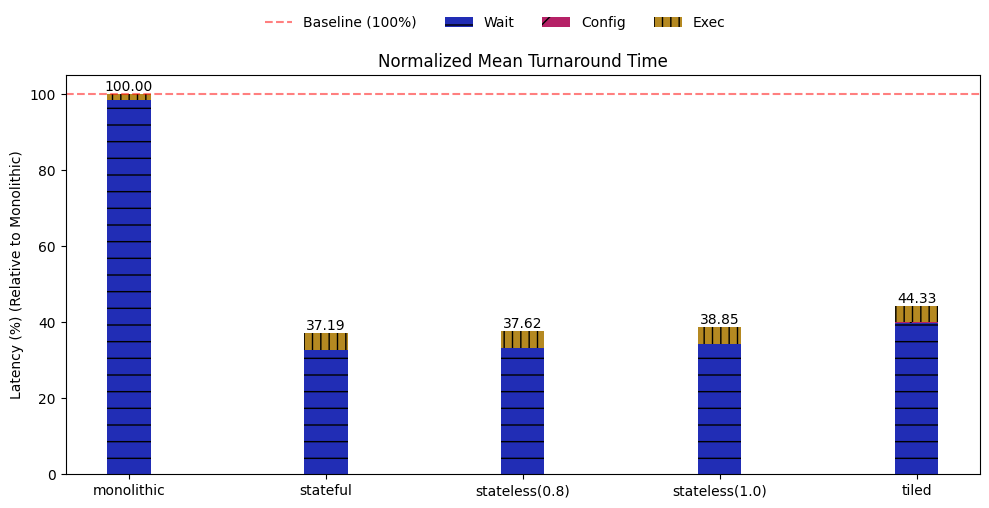

In [634]:
# 1. Calculate the total baseline from the monolithic row
# Sum of the three metrics for the monolithic mode
baseline_total = summary.loc['monolithic', ["mean_wait", "mean_config", "mean_exec"]].sum()

# 2. Create a normalized dataframe (Values as % of Monolithic baseline)
summary_norm = summary[["mean_wait", "mean_config", "mean_exec"]] / baseline_total * 100.0

# 3. Plotting using the normalized data
stacked = summary_norm.to_dict()
labels = summary_norm.index

wait = [stacked['mean_wait'][l] for l in labels]
config = [stacked['mean_config'][l] for l in labels]
exec = [stacked['mean_exec'][l] for l in labels]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))

# Plot bars
_ = ax.bar(x, wait, label='Wait', width=0.22, color=color_stack[0])
[_.set_hatch(hatches[0]) for _ in _]

_ = ax.bar(x, config, bottom=wait, label='Config', width=0.22, color=color_stack[1])
[_.set_hatch(hatches[1]) for _ in _]

bottom_exec = np.array(wait) + np.array(config)
_ = ax.bar(x, exec, bottom=bottom_exec, label='Exec', width=0.22, color=color_stack[2])
[_.set_hatch(hatches[2]) for _ in _]

ax.bar_label(_, label_type='edge', fmt='%.2f')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Latency (%) (Relative to Monolithic)")
ax.set_title("Normalized Mean Turnaround Time")

# Optional: Add a baseline line at 100%
ax.axhline(100, color='red', linestyle='--', alpha=0.5, label='Baseline (100%)')

fig.legend(
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("sm_improvement_stacked.png", dpi=600, bbox_inches="tight")

plt.show()